# Predictive Asset Maintenance Classifier — Phase 2: EDA & Feature Engineering
### Shell Internship Project

In this notebook we will:
1. Explore the distribution of RUL and class balance
2. Visualise how sensors degrade as engines approach failure
3. Identify the most informative sensors using correlation analysis
4. Add rolling mean features to capture degradation trends
5. Save the final feature-engineered dataset for modelling

## 0. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

train = pd.read_csv('data/train_clean.csv')
test  = pd.read_csv('data/test_clean.csv')
feature_cols = pd.read_csv('data/feature_cols.csv', header=None)[0].tolist()
sensor_cols  = [c for c in feature_cols if c.startswith('s_')]

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
print('Features:   ', len(feature_cols))
train.head()

Train shape: (20631, 21)
Test shape:  (100, 21)
Features:    17


,engine_id,cycle,op_1,op_2,op_3,s_2,s_3,s_4,s_7,s_8,...,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL,label
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,...,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191,0
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,...,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190,0
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,...,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189,0
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,...,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188,0
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,...,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187,0


## 1. Class Balance

Check how many samples fall inside vs outside the failure window.
Imbalance here will influence how we evaluate the models in Phase 3.

Label counts:
  0 (healthy)  : 17,531  (85.0%)
  1 (near fail): 3,100  (15.0%)


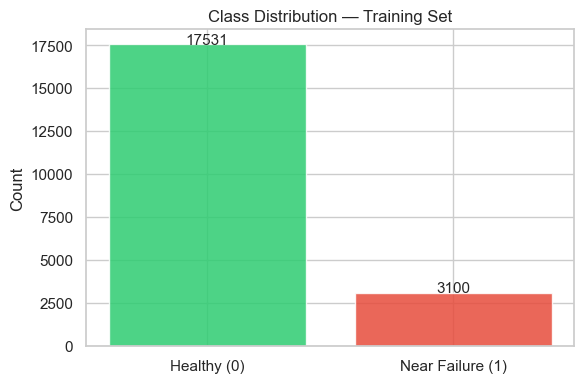

In [2]:
counts = train['label'].value_counts()
pct    = train['label'].value_counts(normalize=True) * 100

print('Label counts:')
print(f'  0 (healthy)  : {counts[0]:,}  ({pct[0]:.1f}%)')
print(f'  1 (near fail): {counts[1]:,}  ({pct[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Healthy (0)', 'Near Failure (1)'], counts.values,
       color=['#2ecc71', '#e74c3c'], alpha=0.85, edgecolor='white')
ax.set_title('Class Distribution — Training Set')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('data/pm_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. RUL Distribution

What does the spread of remaining useful life look like across all engines?

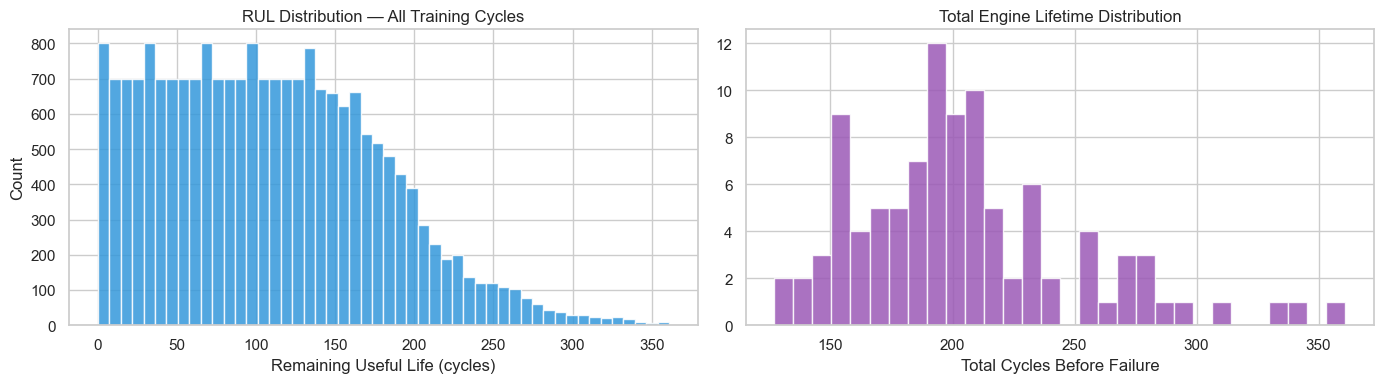

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train['RUL'], bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('RUL Distribution — All Training Cycles')
axes[0].set_xlabel('Remaining Useful Life (cycles)')
axes[0].set_ylabel('Count')

# RUL at first observed cycle per engine (i.e. how long each engine actually lived)
max_rul = train.groupby('engine_id')['RUL'].max()
axes[1].hist(max_rul, bins=30, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].set_title('Total Engine Lifetime Distribution')
axes[1].set_xlabel('Total Cycles Before Failure')

plt.tight_layout()
plt.savefig('data/pm_rul_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Sensor Degradation Patterns

The key hypothesis: sensors behave differently when an engine is healthy vs near failure.
We plot the mean sensor reading grouped by how far from failure the engine is.

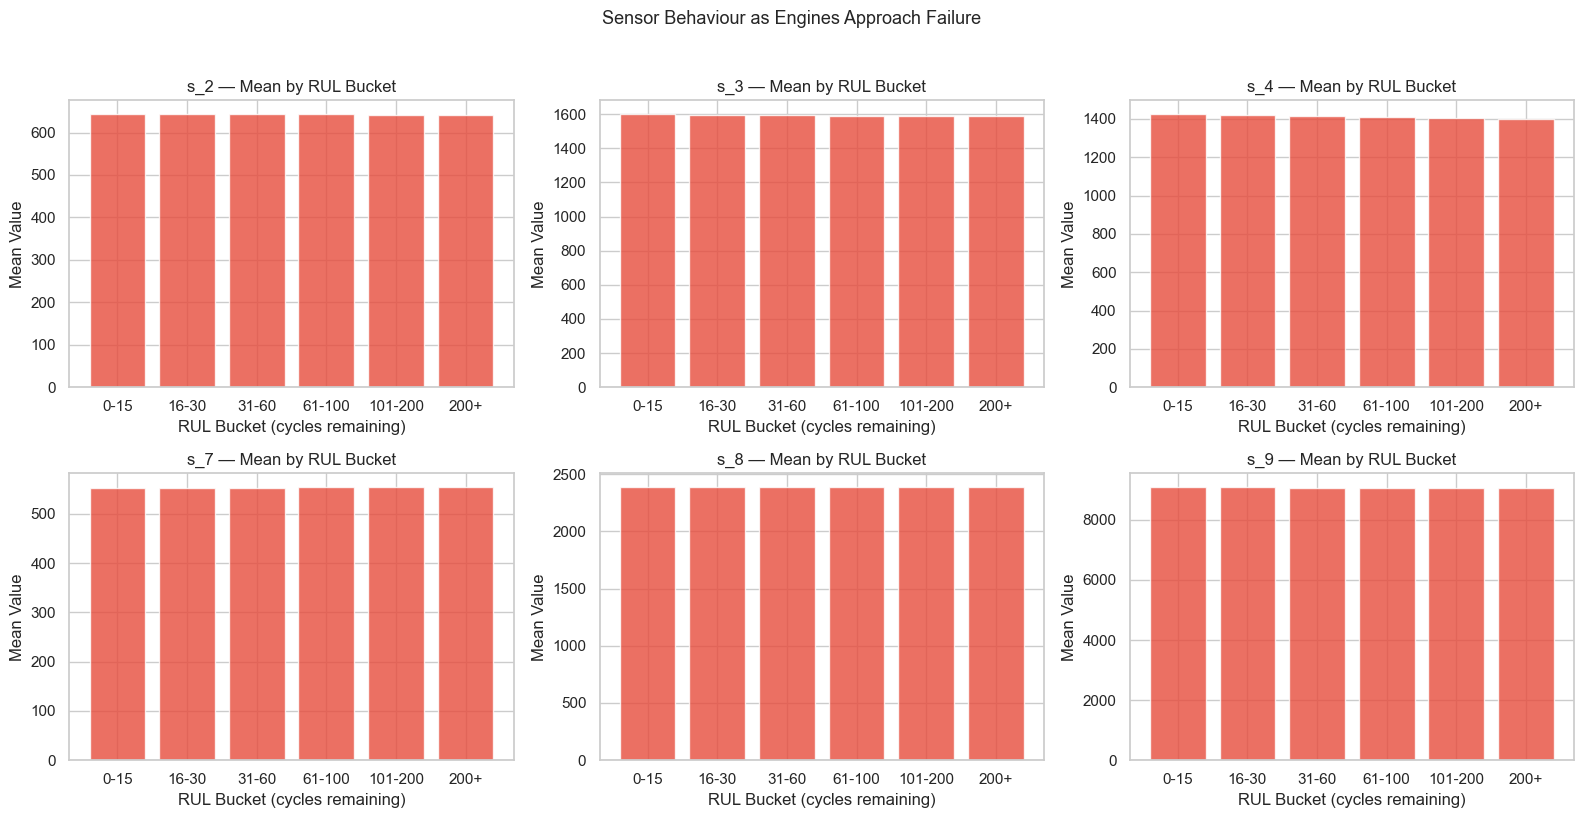

In [4]:
# Bin RUL into buckets and plot mean sensor values per bucket
train['rul_bin'] = pd.cut(train['RUL'], bins=[0, 15, 30, 60, 100, 200, 400],
                           labels=['0-15', '16-30', '31-60', '61-100', '101-200', '200+'])

# Pick 6 sensors to visualise
plot_sensors = sensor_cols[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, sensor in enumerate(plot_sensors):
    grouped = train.groupby('rul_bin', observed=True)[sensor].mean()
    axes[i].bar(grouped.index, grouped.values, color='#e74c3c', alpha=0.8, edgecolor='white')
    axes[i].set_title(f'{sensor} — Mean by RUL Bucket')
    axes[i].set_xlabel('RUL Bucket (cycles remaining)')
    axes[i].set_ylabel('Mean Value')

plt.suptitle('Sensor Behaviour as Engines Approach Failure', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('data/pm_sensor_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation with RUL

Which sensors have the strongest linear relationship with remaining useful life?
High absolute correlation = more useful for predicting failure.

C:\Users\talha\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\talha\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\talha\AppData\Local\Temp\ipykernel_4472\1105377476.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(correlations.index, rotation=45, ha='right')


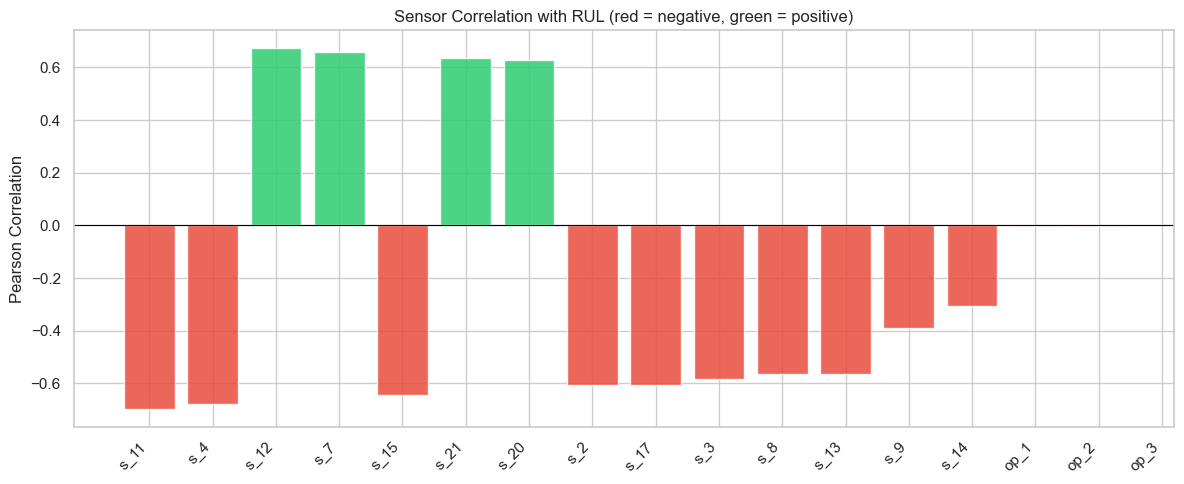

Top 5 most correlated sensors:
s_11    0.696228
s_4     0.678948
s_12    0.671983
s_7     0.657223
s_15    0.642667
dtype: float64


In [5]:
correlations = train[sensor_cols + ['op_1', 'op_2', 'op_3']].corrwith(train['RUL'])
correlations = correlations.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in correlations.values]
ax.bar(correlations.index, correlations.values, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Sensor Correlation with RUL (red = negative, green = positive)')
ax.set_ylabel('Pearson Correlation')
ax.set_xticklabels(correlations.index, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('data/pm_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 most correlated sensors:')
print(correlations.abs().head())

## 5. Sensor Correlation Heatmap

Identify highly correlated sensor pairs — correlated sensors are redundant and can be dropped.

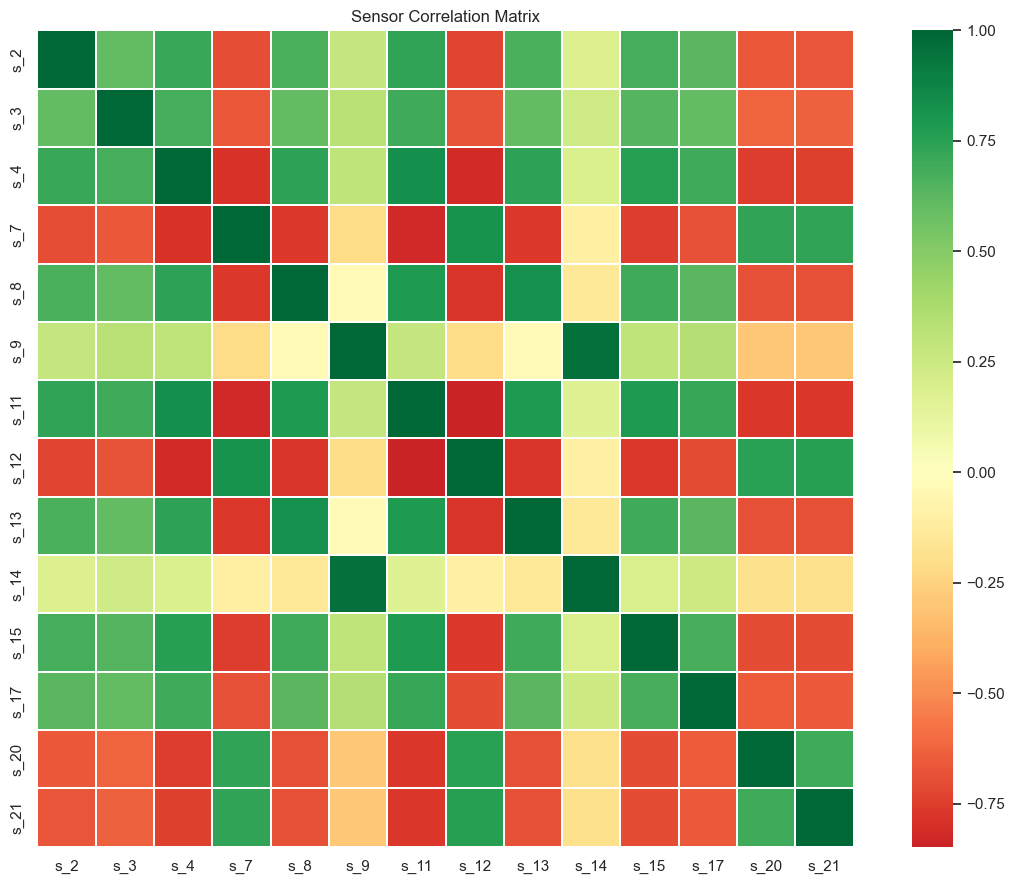

In [6]:
corr_matrix = train[sensor_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, cmap='RdYlGn', center=0, square=True,
            linewidths=0.3, annot=False, ax=ax)
ax.set_title('Sensor Correlation Matrix')
plt.tight_layout()
plt.savefig('data/pm_sensor_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Engineering — Rolling Window Features

Raw sensor readings are noisy. A **rolling mean** smooths short-term noise and better captures the underlying degradation trend — this is a standard technique in industrial ML.

We compute a 5-cycle rolling mean for each sensor.

In [7]:
WINDOW = 5

# Apply rolling mean per engine (not across engines)
def add_rolling_features(df, sensors, window):
    df = df.copy()
    for sensor in sensors:
        df[f'{sensor}_rolling'] = (
            df.groupby('engine_id')[sensor]
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
    return df

train = add_rolling_features(train, sensor_cols, WINDOW)
test  = add_rolling_features(test,  sensor_cols, WINDOW)

rolling_cols = [f'{s}_rolling' for s in sensor_cols]
print(f'Added {len(rolling_cols)} rolling features')
print('New train shape:', train.shape)

Added 14 rolling features
New train shape: (20631, 36)


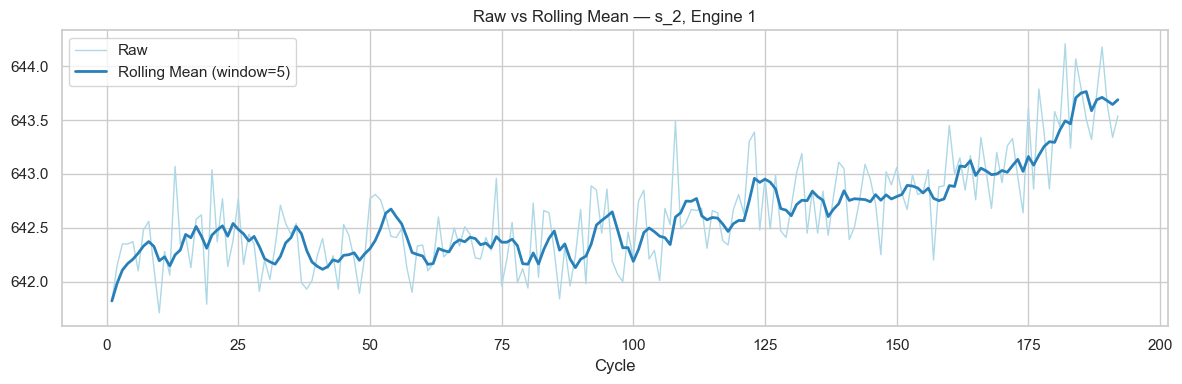

In [8]:
# Visualise raw vs rolling for one sensor on one engine
engine1 = train[train['engine_id'] == 1].sort_values('cycle')
sensor  = sensor_cols[0]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(engine1['cycle'], engine1[sensor],
        color='lightblue', linewidth=1, label='Raw')
ax.plot(engine1['cycle'], engine1[f'{sensor}_rolling'],
        color='#2980b9', linewidth=2, label=f'Rolling Mean (window={WINDOW})')
ax.set_title(f'Raw vs Rolling Mean — {sensor}, Engine 1')
ax.set_xlabel('Cycle')
ax.legend()
plt.tight_layout()
plt.savefig('data/pm_rolling_example.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Final Feature Set & Save

In [9]:
# Final features: original sensors + rolling features + operational settings
op_cols      = ['op_1', 'op_2', 'op_3']
final_features = op_cols + sensor_cols + rolling_cols

print(f'Total features: {len(final_features)}')
print(f'  Operational : {len(op_cols)}')
print(f'  Raw sensors : {len(sensor_cols)}')
print(f'  Rolling     : {len(rolling_cols)}')

# Save
train.to_csv('data/train_featured.csv', index=False)
test.to_csv('data/test_featured.csv',   index=False)
pd.Series(final_features).to_csv('data/final_features.csv', index=False, header=False)

print('\nSaved: data/train_featured.csv')
print('Saved: data/test_featured.csv')
print('Saved: data/final_features.csv')

Total features: 31
  Operational : 3
  Raw sensors : 14
  Rolling     : 14

Saved: data/train_featured.csv
Saved: data/test_featured.csv
Saved: data/final_features.csv


---
## Phase 2 Complete!

**Key findings to note for your write-up / interview:**
- Dataset is imbalanced — check your label counts above, this means F1-score matters more than accuracy
- Several sensors show clear monotonic degradation as engines approach failure
- Rolling mean features smooth noise and better capture the degradation trend
- Some sensors are highly correlated — tree-based models (XGBoost, Random Forest) handle this naturally

**Next up: Phase 3 — Modelling with Random Forest, XGBoost and Neural Network**